# DS_P599_(Solar_Panel_Regression),GROUP_05
Objective:
The variable to be predicted is continuous (energy production). Therefore, this is an Regression project. The primary goal is to model energy production as a function of environmental variables

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load The Dataset
df = pd.read_csv("solarpowergeneration.csv")
display(df.head())

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
df.shape

(2920, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


## Exploratory Data Analysis (EDA)

In [6]:
# Check the number of missing values in each column
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    1
average-pressure-(period)      0
power-generated                0
dtype: int64

In [7]:
df['average-wind-speed-(period)'].mean()

10.129153819801301

In [8]:
df.fillna({'average-wind-speed-(period)':df['average-wind-speed-(period)'].mean()},inplace=True)

In [9]:
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    0
average-pressure-(period)      0
power-generated                0
dtype: int64

In [10]:
df.shape

(2920, 10)

In [11]:
## check for duplicates
df.duplicated().sum()

0

In [12]:
df[df.duplicated()].shape

(0, 10)

In [13]:
# Calculate and display descriptive statistics
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.260303,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


In [14]:
#Histogram plot

In [15]:
df.columns

Index(['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)', 'power-generated'],
      dtype='object')

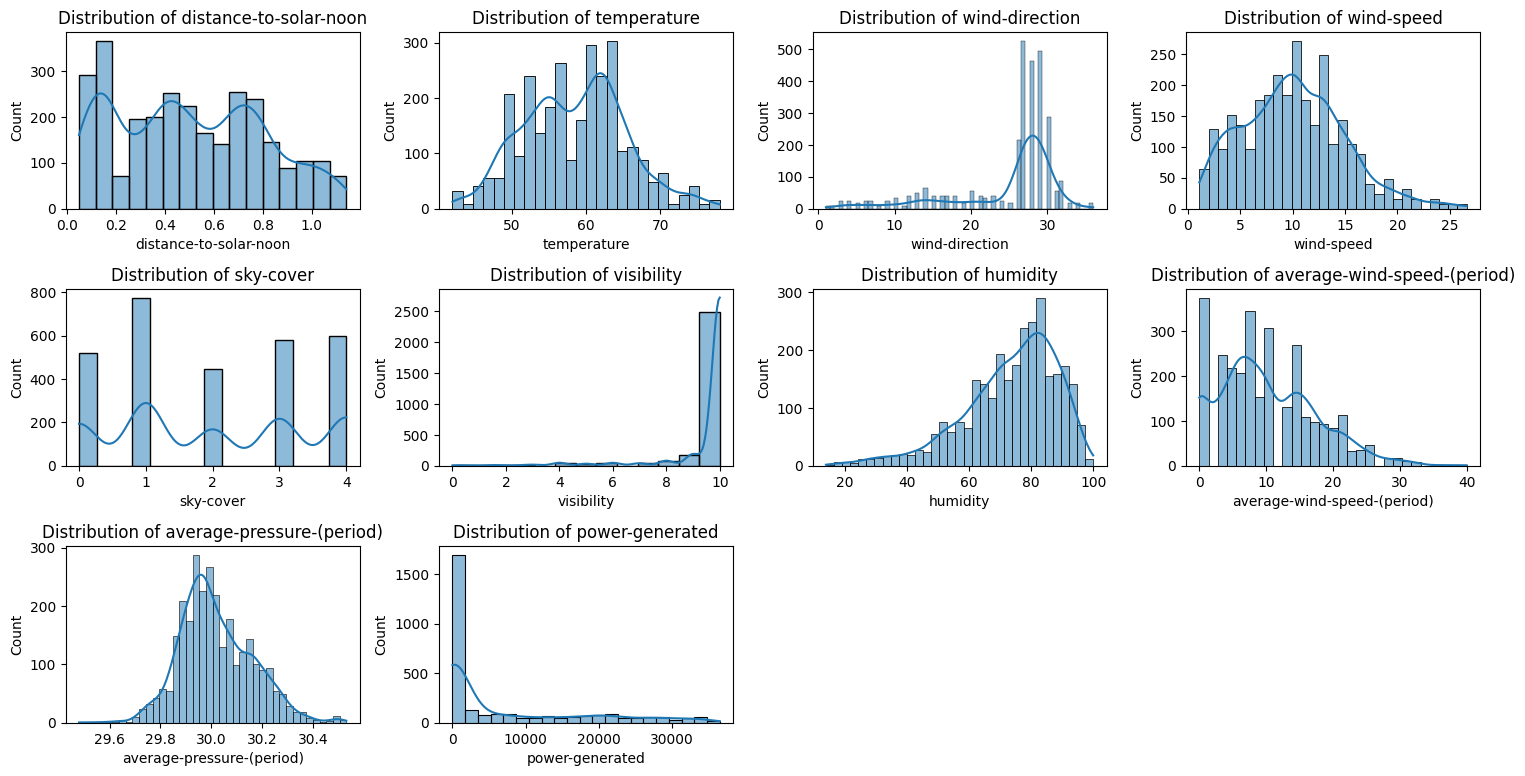

In [16]:
numerical_cols = ['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed', 'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)', 'average-pressure-(period)', 'power-generated']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

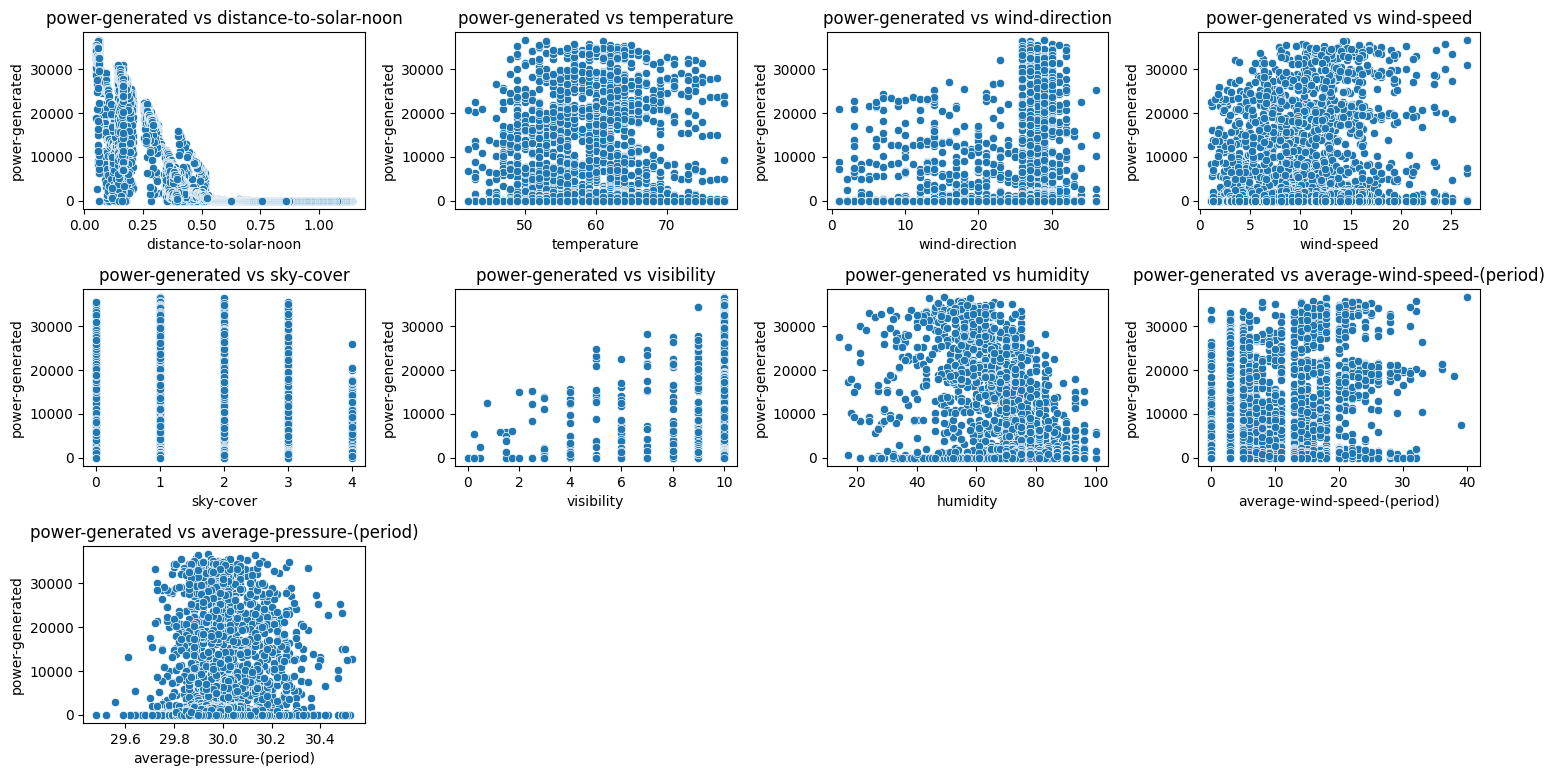

In [17]:
# Create scatter plots for 'power-generated' against other numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    if col != 'power-generated':
        plt.subplot(4, 4, i + 1)
        sns.scatterplot(x=df[col], y=df['power-generated'])
        plt.title(f'power-generated vs {col}')
plt.tight_layout()
plt.show()

In [18]:
# Calculate and display the correlation matrix
print("\nCorrelation Matrix:")
correlation_matrix = df.corr()
display(correlation_matrix)


Correlation Matrix:


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
distance-to-solar-noon,1.000000,-0.145207,-0.118010,-0.145073,-0.015184,0.065807,0.368964,-0.214887,0.082505,-0.746681
temperature,-0.145207,1.000000,0.342146,0.096267,-0.230672,0.194110,-0.221463,0.054545,-0.435723,0.132193
wind-direction,-0.118010,0.342146,1.000000,0.341529,-0.137140,0.203445,-0.095917,0.229706,-0.272405,0.146788
wind-speed,-0.145073,0.096267,0.341529,1.000000,0.107793,0.184778,0.004901,0.673364,-0.379752,0.142641
sky-cover,-0.015184,-0.230672,-0.137140,0.107793,1.000000,-0.223523,0.394576,0.044301,-0.091512,-0.187236
visibility,0.065807,0.194110,0.203445,0.184778,-0.223523,1.000000,-0.291320,0.143224,-0.105345,0.076536
humidity,0.368964,-0.221463,-0.095917,0.004901,0.394576,-0.291320,1.000000,-0.217959,0.018489,-0.522545
average-wind-speed-(period),-0.214887,0.054545,0.229706,0.673364,0.044301,0.143224,-0.217959,1.000000,-0.293406,0.278154
average-pressure-(period),0.082505,-0.435723,-0.272405,-0.379752,-0.091512,-0.105345,0.018489,-0.293406,1.000000,-0.036771
power-generated,-0.746681,0.132193,0.146788,0.142641,-0.187236,0.076536,-0.522545,0.278154,-0.036771,1.000000


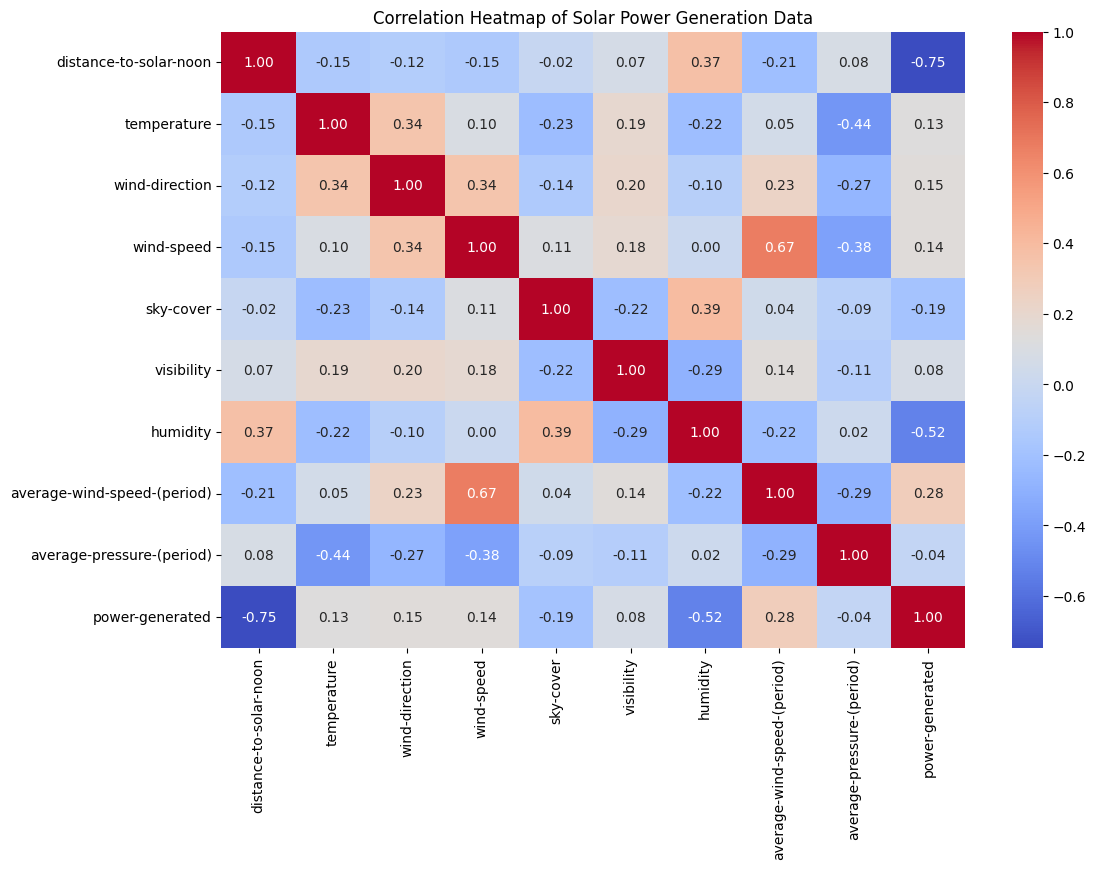

In [19]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Solar Power Generation Data')
plt.show()

In [20]:
#Check for outerlier

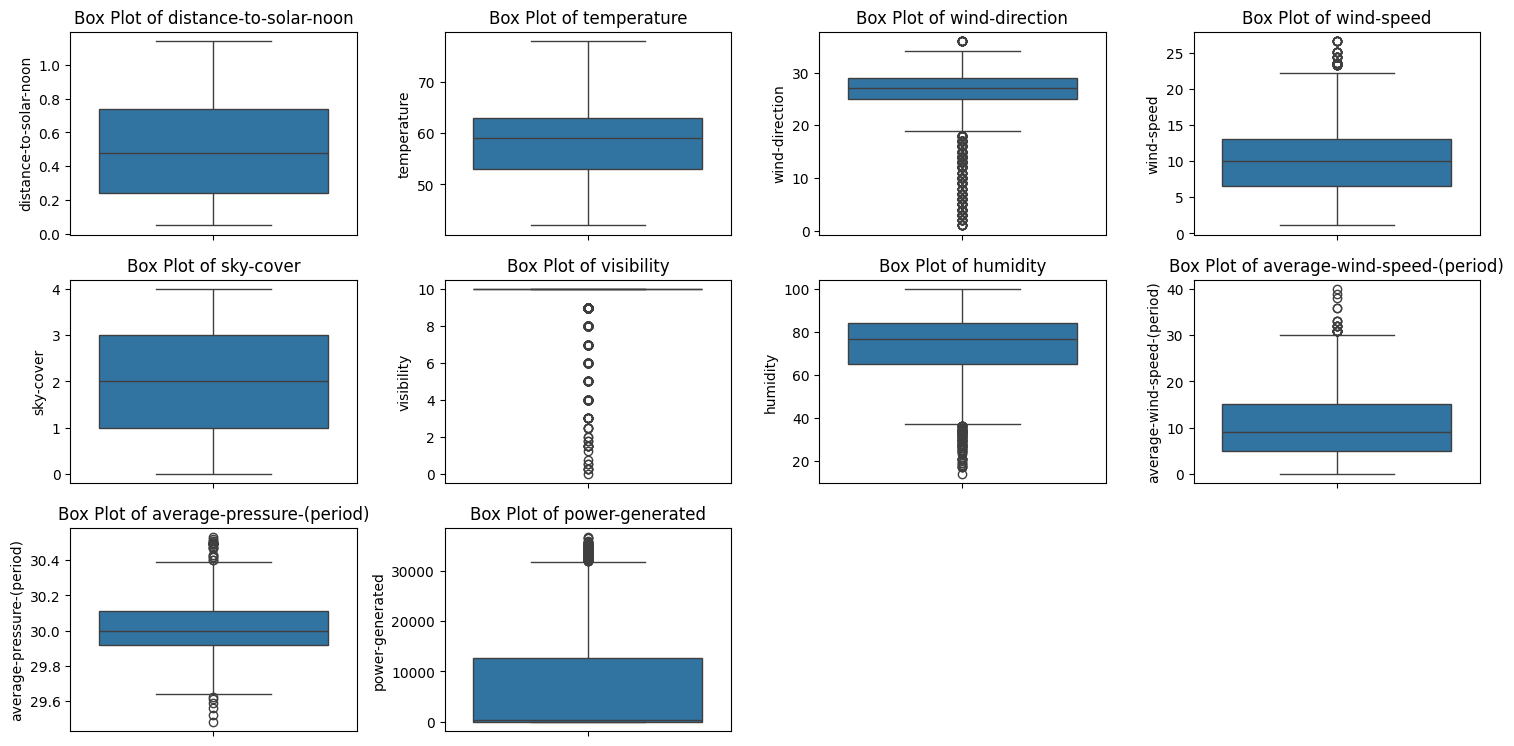

In [21]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

In [22]:
## outlier capping
def outiler_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR=Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x:Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outiler_capping(df,col)

In [23]:
## for checking outlier another time

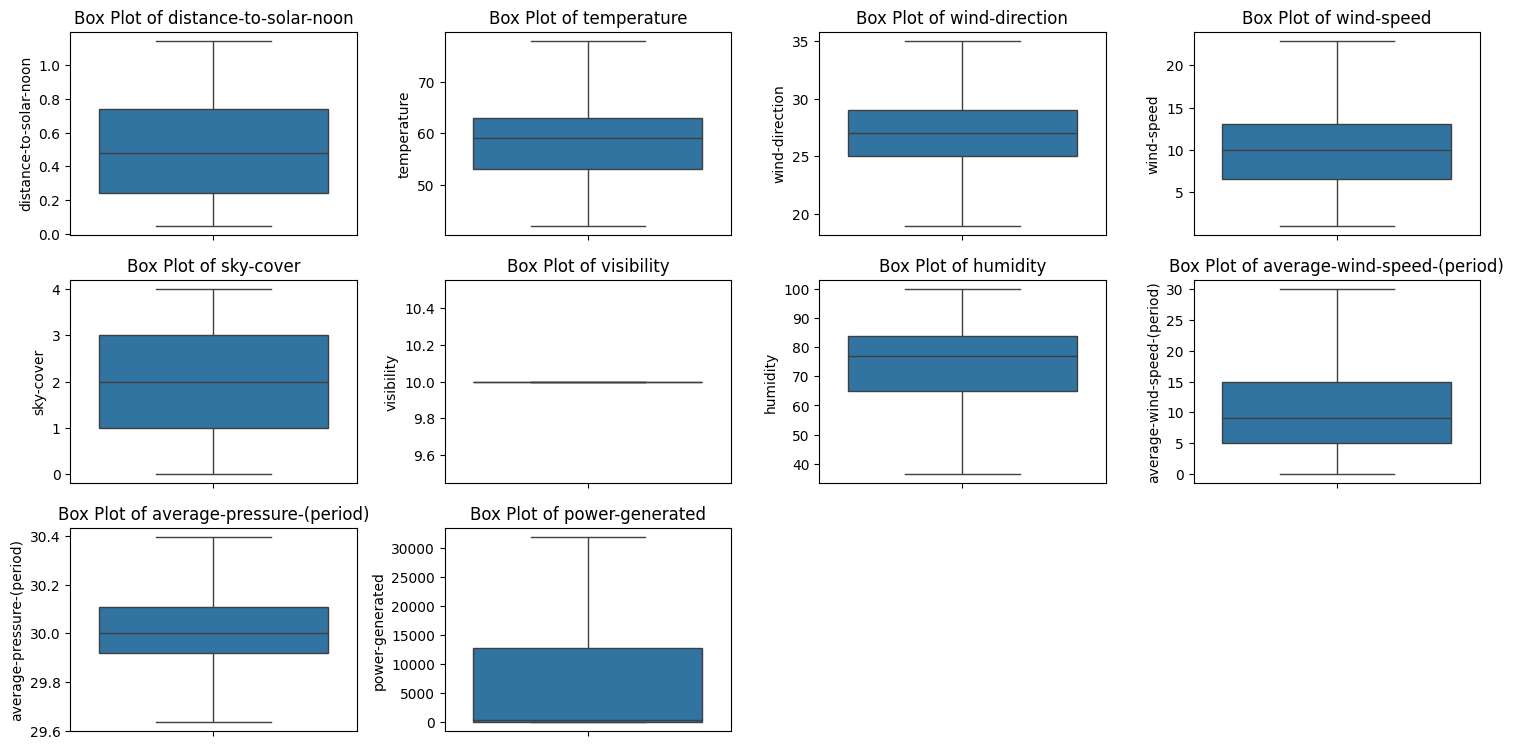

In [24]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

# Prepare Data for Modeling
## Select features for modeling

In [25]:
# Select features for modeling
features = ['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)']

X = df[features]
y = df['power-generated']

In [26]:
# X = df.drop(columns=['power-generated'])
# y = df['power-generated']

In [27]:
# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# # Save scaler for later
# joblib.dump(scaler, "scaler.joblib")
# print("Saved scaler -> scaler.joblib")

## Model Building and Evaluation

## Decision Tree --Model--

In [29]:
#Decision Tree --Model--
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
#-- Prediction --
pred_dt = dt.predict(X_test)

In [31]:
#-- Metrics --
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2_dt = r2_score(y_test, pred_dt)
mse_dt = mean_squared_error(y_test, pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, pred_dt)

In [32]:
print("Decision Tree R2:", r2_dt)
print("Decision Tree RMSE:", rmse_dt)
print("Decision Tree MAE:", mae_dt)

Decision Tree R2: 0.8143195716155183
Decision Tree RMSE: 4345.727031136723
Decision Tree MAE: 1912.6669520547946


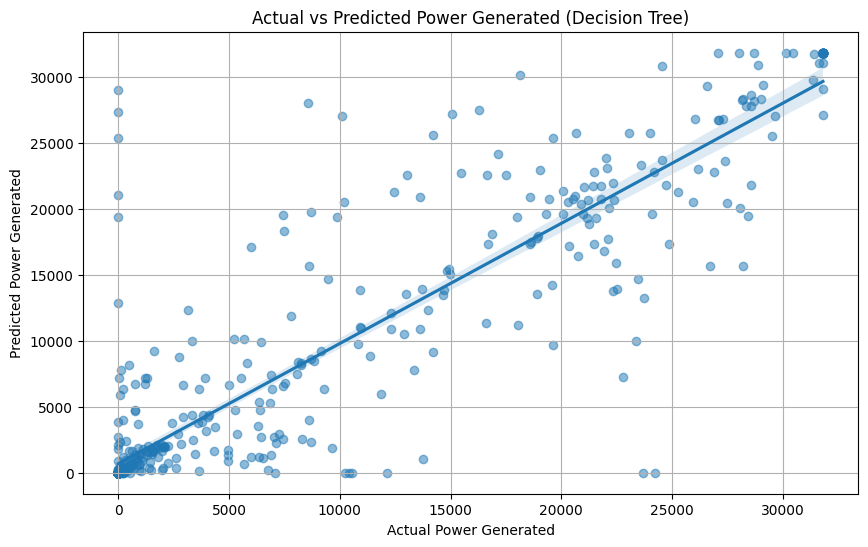

In [33]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=pred_dt, scatter_kws={'alpha':0.5})
plt.xlabel("Actual Power Generated")
plt.ylabel("Predicted Power Generated")
plt.title("Actual vs Predicted Power Generated (Decision Tree)")
plt.grid(True)
plt.show()

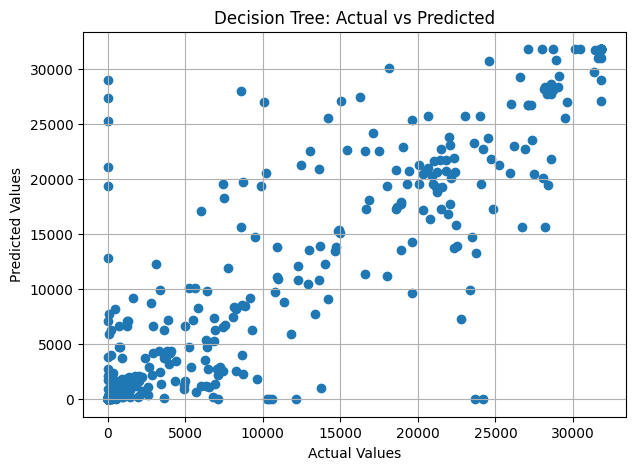

In [34]:
#PLOT 1 — Actual vs Predicted Scatter Plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_dt)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted")
plt.grid(True)
plt.show()

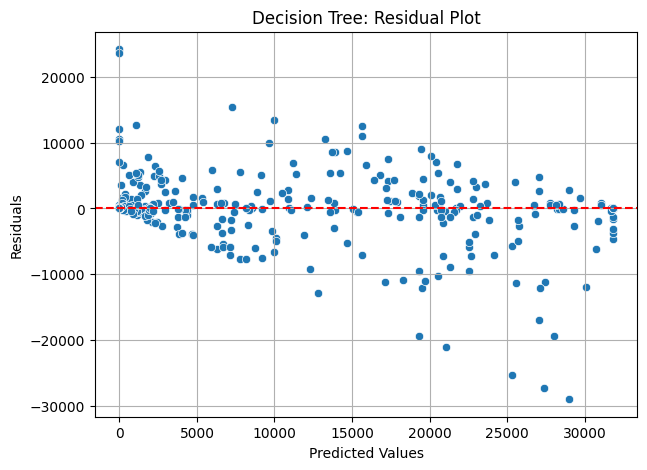

In [35]:
#PLOT 2 — Residual Plot
residuals = y_test - pred_dt

plt.figure(figsize=(7,5))
sns.scatterplot(x=pred_dt, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Decision Tree: Residual Plot")
plt.grid(True)
plt.show()

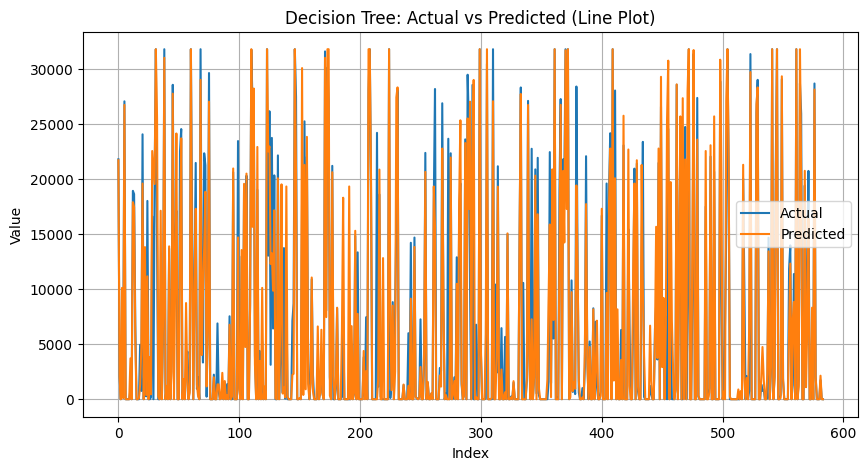

In [36]:
#PLOT 3 — Actual vs Predicted Line Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_dt, label="Predicted")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Decision Tree: Actual vs Predicted (Line Plot)")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 800x600 with 0 Axes>

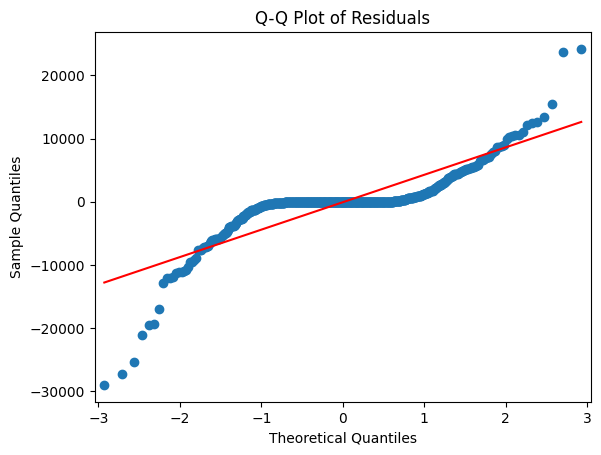

In [37]:
import statsmodels.api as sm
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

## Random Forest--Model--

In [38]:
#Random Forest--Model--
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
#--Prediction--
pred_rf = rf.predict(X_test)

In [40]:
#-- Metrics--
r2_rf = r2_score(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf) # Calculate MSE
rmse_rf = np.sqrt(mse_rf) # Then take square root for RMSE
mae_rf = mean_absolute_error(y_test, pred_rf)

In [41]:
print("Random Forest R2:", r2_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest R2: 0.8874863475627357
Random Forest RMSE: 3382.8441519830358
Random Forest MAE: 1526.752970890411


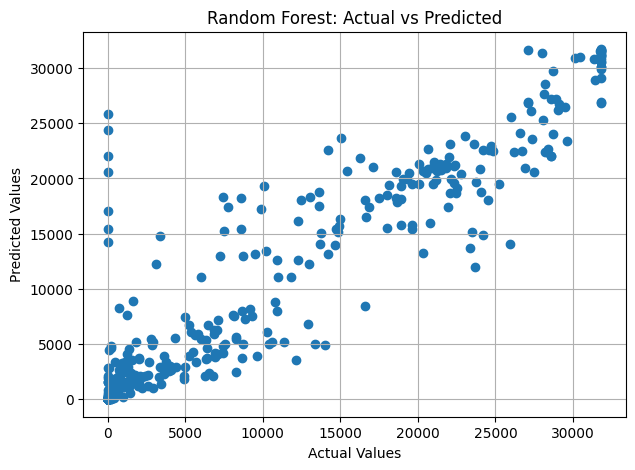

In [42]:
#PLOT 1 — Actual vs Predicted Scatter Plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.show()

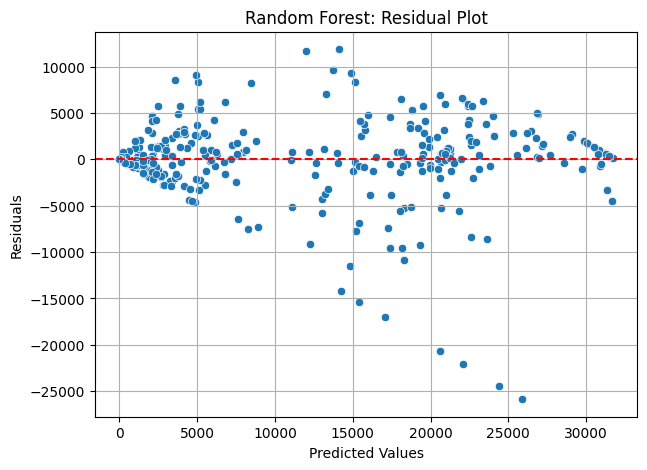

In [43]:
#PLOT 2 — Residual Plot
residuals_rf = y_test - pred_rf

plt.figure(figsize=(7,5))
sns.scatterplot(x=pred_rf, y=residuals_rf)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")
plt.grid(True)
plt.show()

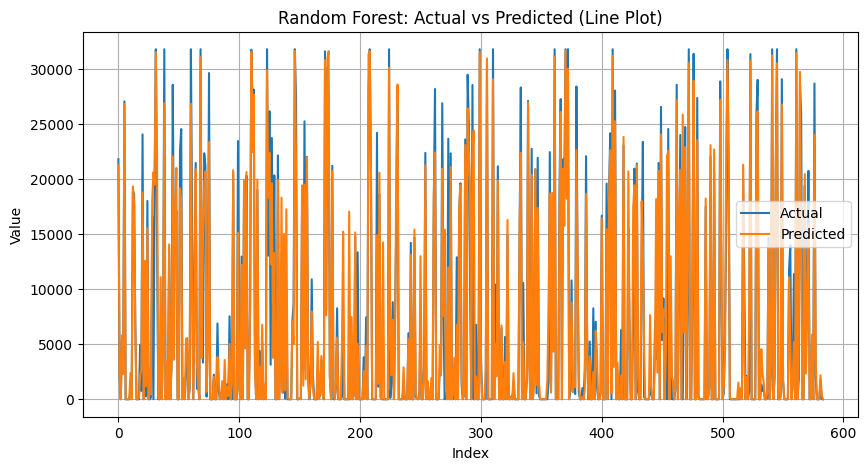

In [44]:
#PLOT 3 — Actual vs Predicted Line Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual"),#color="red")
plt.plot(pred_rf, label="Predicted")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Random Forest: Actual vs Predicted (Line Plot)")
plt.legend()
plt.grid(True)
plt.show()

## Gradient Boosting--Model--

In [45]:
#Gradient Boosting--Model--
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [46]:
#-- Prediction--
pred_gb = gb.predict(X_test)

In [47]:
#--Metrics--
r2_gb = r2_score(y_test, pred_gb)
mse_gb = mean_squared_error(y_test, pred_gb)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test, pred_gb)

In [48]:
print("Gradient Boosting R2:", r2_gb)
print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting MAE:", mae_gb)

Gradient Boosting R2: 0.9051484605582146
Gradient Boosting RMSE: 3106.000853039399
Gradient Boosting MAE: 1633.3710400951281


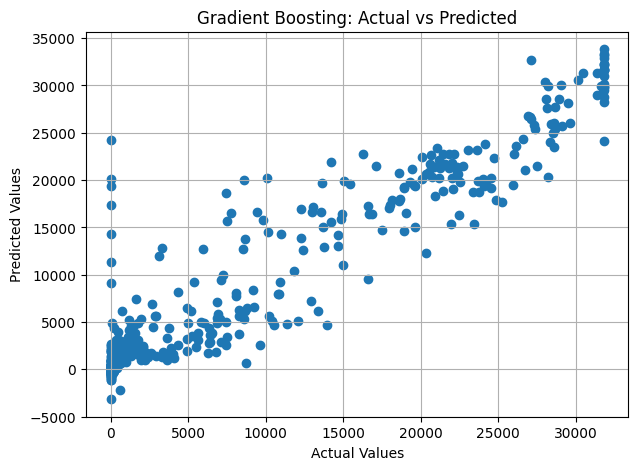

In [49]:
#PLOT 1 — Actual vs Predicted Scatter Plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_gb)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Gradient Boosting: Actual vs Predicted")
plt.grid(True)
plt.show()

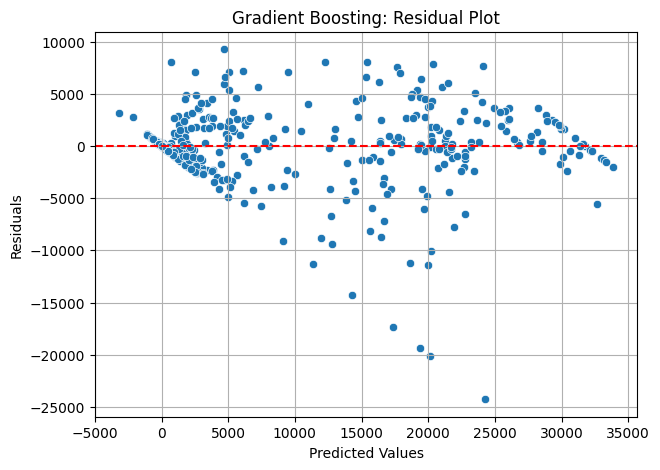

In [50]:
#PLOT 2 — Residual Plot
residuals_gb = y_test - pred_gb

plt.figure(figsize=(7,5))
sns.scatterplot(x=pred_gb, y=residuals_gb)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Gradient Boosting: Residual Plot")
plt.grid(True)
plt.show()

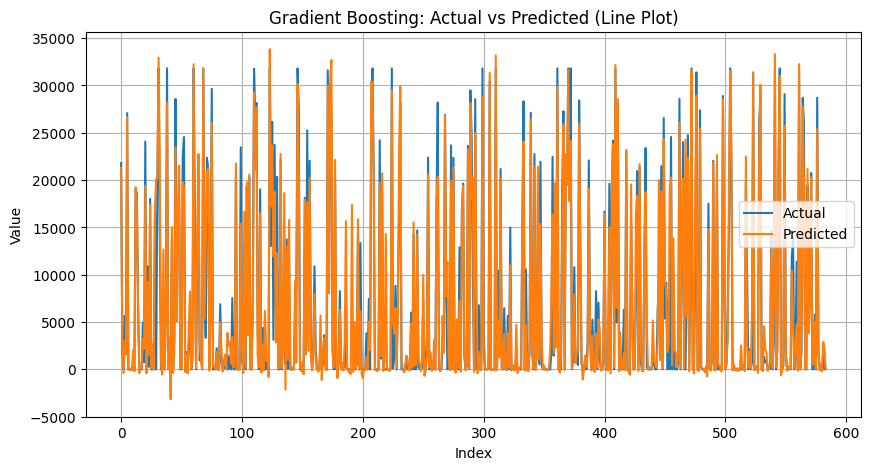

In [51]:
#PLOT 3 — Actual vs Predicted Line Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_gb, label="Predicted")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Gradient Boosting: Actual vs Predicted (Line Plot)")
plt.legend()
plt.grid(True)
plt.show()

## XGBoost (XGBRegressor)

In [52]:
#XGBoost (XGBRegressor)
import xgboost as xgb
from xgboost import XGBRegressor
xgbr = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0)
xgbr.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [53]:
#--Prediction--
pred_xgb = xgbr.predict(X_test)

In [54]:
#--Metrics--
r2_xgb = r2_score(y_test, pred_xgb)
mse_xgb = mean_squared_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, pred_xgb)

In [55]:
print("XGBoost R2:", r2_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAE:", mae_xgb)

XGBoost R2: 0.903243965894204
XGBoost RMSE: 3137.02809474946
XGBoost MAE: 1509.2084527822492


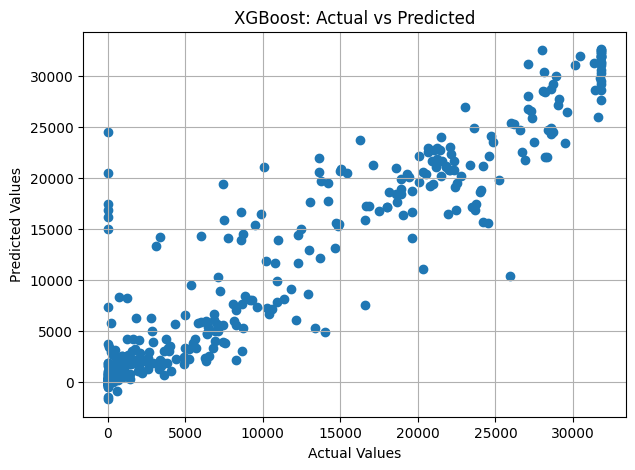

In [56]:
#PLOT 1 — Actual vs Predicted Scatter Plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_xgb)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("XGBoost: Actual vs Predicted")
plt.grid(True)
plt.show()

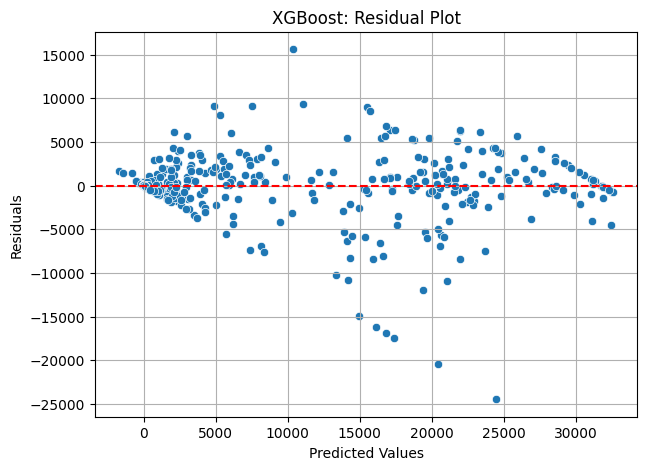

In [57]:
#PLOT 2 — Residual Plot
residuals_xgb = y_test - pred_xgb

plt.figure(figsize=(7,5))
sns.scatterplot(x=pred_xgb, y=residuals_xgb)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("XGBoost: Residual Plot")
plt.grid(True)
plt.show()

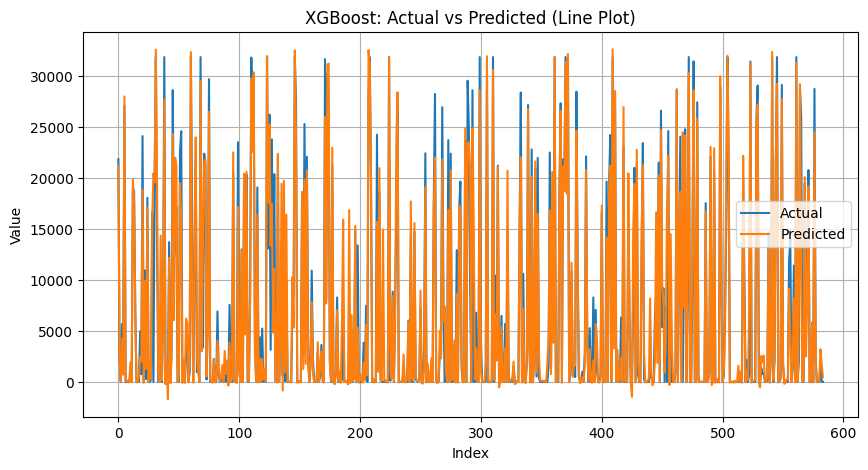

In [58]:
#PLOT 3 — Actual vs Predicted Line Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_xgb, label="Predicted")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("XGBoost: Actual vs Predicted (Line Plot)")
plt.legend()
plt.grid(True)
plt.show()

## Compare results

In [59]:
# Compare results
results = pd.DataFrame({
    "Model": ["DecisionTree", "RandomForest", "GradientBoosting", "XGBoost"],
    "R2": [r2_dt, r2_rf, r2_gb, r2_xgb],
    "RMSE": [rmse_dt, rmse_rf, rmse_gb, rmse_xgb],
    "MAE": [mae_dt, mae_rf, mae_gb, mae_xgb]
}).sort_values(by="R2", ascending=False).reset_index(drop=True)
display(results)

,Model,R2,RMSE,MAE
0,GradientBoosting,0.905148,3106.000853,1633.371040
1,XGBoost,0.903244,3137.028095,1509.208453
2,RandomForest,0.887486,3382.844152,1526.752971
3,DecisionTree,0.814320,4345.727031,1912.666952


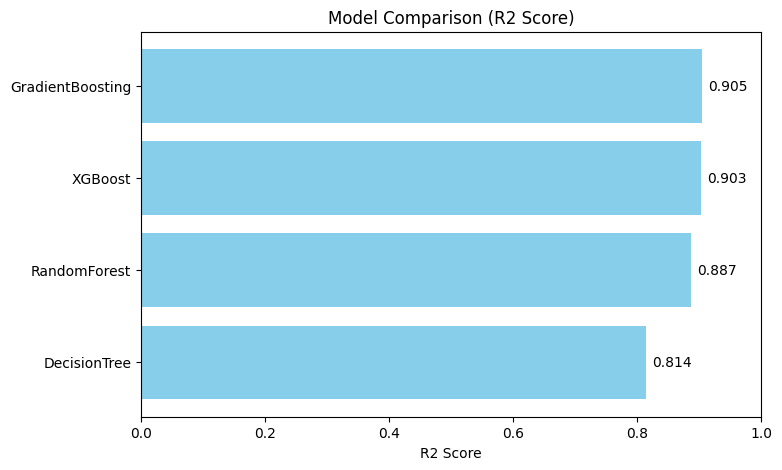

In [60]:
plt.figure(figsize=(8,5))
plt.barh(results["Model"], results["R2"], color="skyblue")

# Add value labels on bars
for index, value in enumerate(results["R2"]):
    plt.text(value + 0.01, index, f"{value:.3f}", va='center')

plt.xlabel("R2 Score")
plt.title("Model Comparison (R2 Score)")
plt.gca().invert_yaxis()
plt.xlim(0, 1)   # optional
plt.show()


In [61]:
import joblib
print("joblib imported successfully.")

joblib imported successfully.


In [62]:
joblib.dump(gb, 'gradient_boosting_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("Gradient Boosting model and StandardScaler saved successfully.")

Gradient Boosting model and StandardScaler saved successfully.
